In [2]:
import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')
RANDOMSEED=1727

os.environ['PYTHONHASHSEED'] = str(RANDOMSEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ":4096:2"

In [3]:
import torch,random
import tensorflow as tf
import numpy as np

tf.config.experimental.enable_op_determinism()
torch.use_deterministic_algorithms(True)

def random_seed(seed=RANDOMSEED, use_cuda=False):
  np.random.seed(seed) # cpu vars
  torch.manual_seed(seed) # cpu vars
  random.seed(seed) # Python
  tf.random.set_seed(seed)
  tf.keras.utils.set_random_seed(seed)
  
  if use_cuda: 
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # gpu vars
    torch.backends.cudnn.deterministic = True  #needed
    torch.backends.cudnn.benchmark = False
    
random_seed(RANDOMSEED)
tf.config.set_visible_devices([], 'GPU')

In [4]:
from pathlib import Path

cred_path = Path('~/.kaggle/access_token').expanduser()
if not cred_path.exists():
  cred_path.parent.mkdir(exist_ok=True)
  cred_path.write_text("KGAT_9f6b15aaf6f7637b8497dfb3c56c079e")
  cred_path.chmod(0o600)

In [5]:
nname = Path('digit-recognizer')

if not iskaggle:
  if not nname.exists():
    import zipfile,kaggle
    kaggle.api.authenticate()
    kaggle.api.competition_download_cli(str(nname))
    zipfile.ZipFile(f'{nname}.zip').extractall(nname)
else:
  # /kaggle/input/competitions/nlp-getting-started/train.csv
  nname = Path(f'/kaggle/input/competitions/{nname}')

# %pip install -q datasets
!dir /o:g /w {nname}
# !ls {nname}

 Volume in drive C is Windows
 Volume Serial Number is 6291-898F

 Directory of c:\Users\longnuub\learning-programming-languages\learning-python\kaggle\digit-recognizer

[..]                    [.]                     test.csv
train.csv               sample_submission.csv   
               3 File(s)    128.134.246 bytes
               2 Dir(s)  137.426.882.560 bytes free


In [6]:
import pandas as pd
train=pd.read_csv(nname/"train.csv")
test=pd.read_csv(nname/"test.csv")

# drop the `id` col for training data ONLY, we need the id for test preds later
# train.drop(columns=["id"],inplace=True)

In [7]:
xtrain=train.copy().drop(columns="label")
xtest=test.copy()
ytrain=train["label"]

xtrain_r=xtrain.values.reshape(xtrain.shape[0],28,28) # (amount of input rows, sizeX, sizeY)
xtrain_r[:2] # first two input images

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]]], shape=(2, 28, 28))

In [8]:
# normalize
xtrain=xtrain.astype("float32") / 255.0
xtest=xtest.astype("float32") / 255.0

# reshape into img
xtrain=xtrain.values.reshape(-1,28,28,1)
xtest=xtest.values.reshape(-1,28,28,1)

# some visualizations

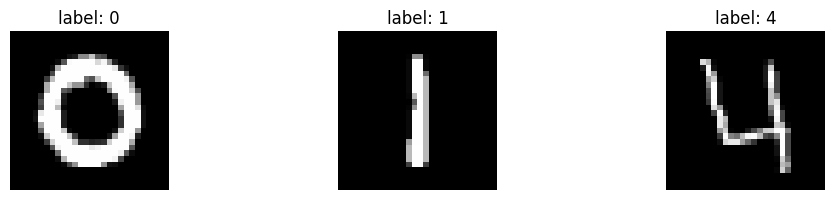

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))
for i in range(1,4):
    plt.subplot(3,3,i)
    plt.imshow(xtrain_r[i],cmap="gray")
    plt.title("label: " + str(ytrain[i]))
    plt.axis(False)

# model code

In [34]:
from tensorflow import keras
from keras import layers, optimizers, Sequential, metrics
from keras.initializers import glorot_uniform

init=glorot_uniform(seed=RANDOMSEED)

model=Sequential([
    layers.Input(shape=(28,28,1)),

    # data augmentation
    layers.RandomRotation(factor=0.1,seed=RANDOMSEED),
    layers.RandomTranslation(height_factor=0.02,width_factor=0.02,seed=RANDOMSEED),
    layers.RandomGaussianBlur(factor=0.03,seed=RANDOMSEED),
    layers.RandomShear(x_factor=0.07,y_factor=0.07,seed=RANDOMSEED),
    layers.RandomZoom(height_factor=0.05,seed=RANDOMSEED),

    # neural network layers
    layers.Conv2D(32,kernel_size=3,activation="relu",kernel_initializer=init),
    layers.MaxPooling2D(),

    layers.Conv2D(64,kernel_size=3,activation="relu",kernel_initializer=init),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128,activation="relu",kernel_initializer=init),
    layers.Dropout(0.3,seed=RANDOMSEED),
    layers.Dense(10,activation="softmax",kernel_initializer=init) # output
])

In [35]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation_4               │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_4            │ (None, 28, 28, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_gaussian_blur_4          │ (None, 28, 28, 1)      │             0 │
│ (RandomGaussianBlur)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_shear_4 (RandomShear)    │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_4 (RandomZoom)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    metrics=["accuracy"],
    loss="sparse_categorical_crossentropy",
)

In [37]:
from keras import callbacks

earlystop=callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=5,
    verbose=True,
    restore_best_weights=True,
)

history=model.fit(
    xtrain,ytrain,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[earlystop]
)

Epoch 1/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.8396 - loss: 0.5009 - val_accuracy: 0.9674 - val_loss: 0.0938
Epoch 2/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.9400 - loss: 0.1963 - val_accuracy: 0.9756 - val_loss: 0.0746
Epoch 3/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9525 - loss: 0.1508 - val_accuracy: 0.9765 - val_loss: 0.0729
Epoch 4/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9598 - loss: 0.1296 - val_accuracy: 0.9806 - val_loss: 0.0606
Epoch 5/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9657 - loss: 0.1100 - val_accuracy: 0.9854 - val_loss: 0.0508
Epoch 6/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9681 - loss: 0.1040 - val_accuracy: 0.9870 - val_loss: 0.0454
Epoch 7/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9716 - loss: 0.0954 - val_accuracy: 0.9885 - val_loss: 0.0430
Epoch 8/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9737 - loss: 0.0857 - 

<Axes: >

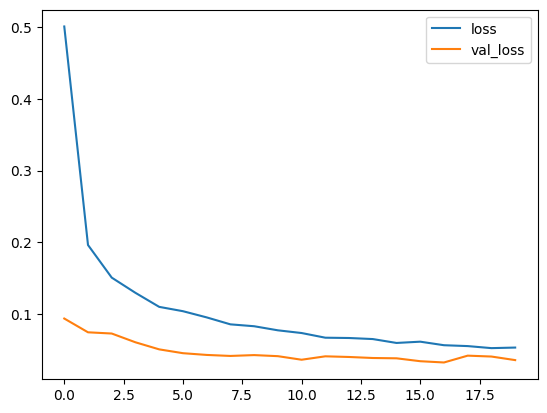

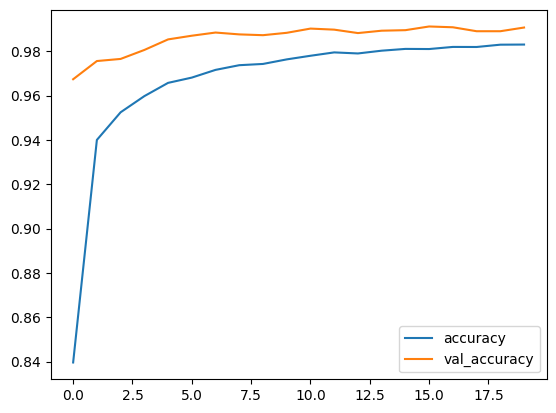

In [38]:
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot()

# prediction

In [39]:
preds=model.predict(xtest)
pred_labels = np.argmax(preds, axis=1)

875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


In [40]:
subs_df = pd.DataFrame({
    "ImageId": np.arange(1, len(pred_labels)+1),
    "Label": pred_labels
})

In [41]:
# subs_df.shape
subs_df.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3


In [42]:
subs_df.to_csv("submission.csv", index=False)